<a href="https://colab.research.google.com/github/begumsoeba786-art/task1-ml-classification1/blob/main/Task4_Responsible_AId0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e61ace68481d272cb569de24fcc5a022d7dcb9f39bda09d4056cf057782140a8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import shap
import lime
import lime.lime_tabular
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Reload dataset and model
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain best model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model loaded and ready!")

Model loaded and ready!


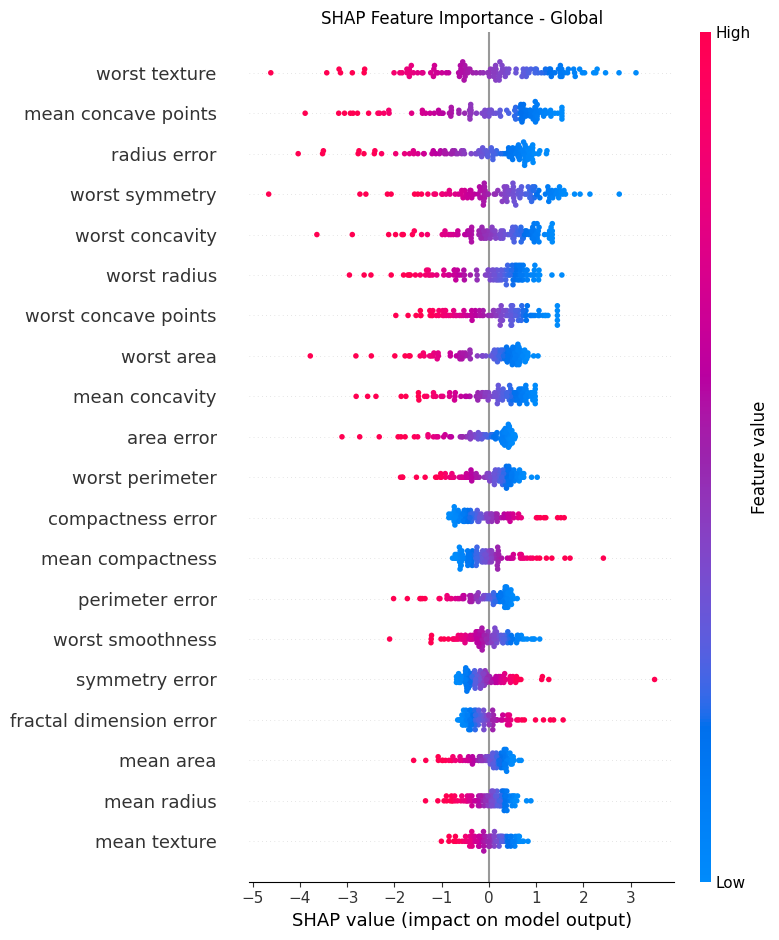

SHAP summary plot saved!


In [ ]:
# Create SHAP explainer
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot - most important features
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=data.feature_names,
    show=False
)
plt.title("SHAP Feature Importance - Global")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

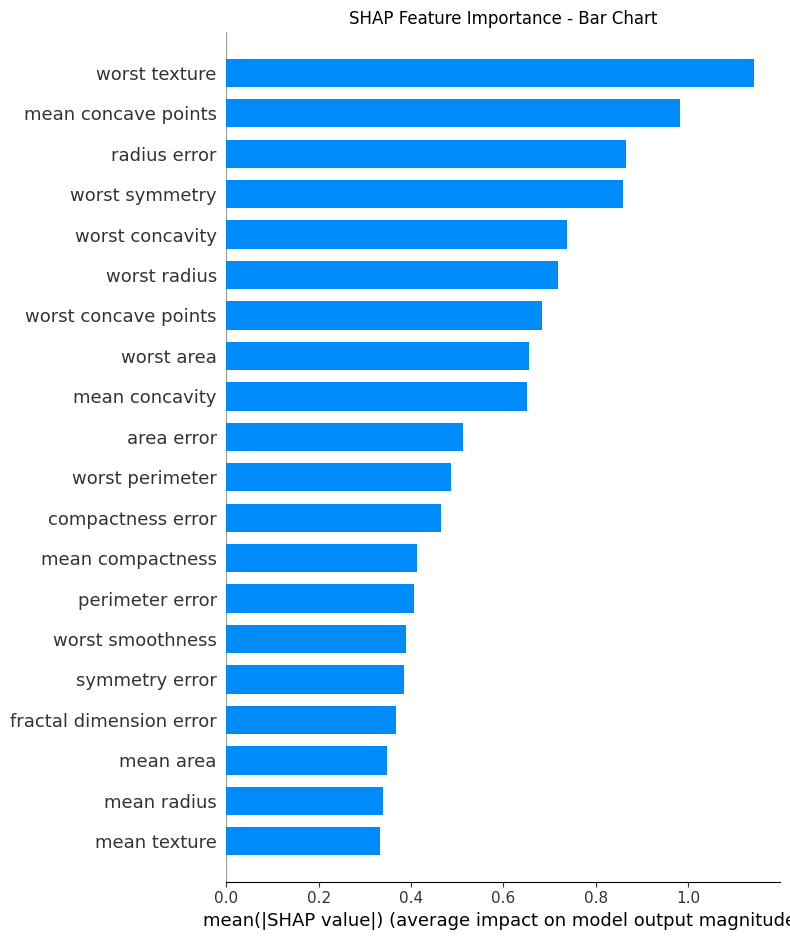

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=data.feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance - Bar Chart")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

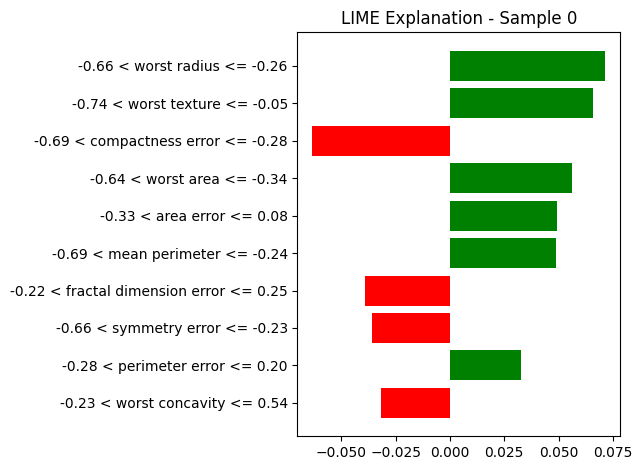

LIME explanation saved!


In [ ]:
# LIME explains individual predictions
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=data.feature_names,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)

# Explain first test sample
i = 0
exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    model.predict_proba,
    num_features=10
)

exp.as_pyplot_figure()
plt.title(f"LIME Explanation - Sample {i}")
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()
print("LIME explanation saved!")

In [ ]:
# Check model performance across groups
# Split by mean radius (tumor size as proxy group)
X_test_df = X_test.copy()
X_test_df['target'] = y_test.values
X_test_df['predicted'] = model.predict(X_test_scaled)

# Group by tumor size
median_radius = X_test_df['mean radius'].median()
X_test_df['size_group'] = X_test_df['mean radius'].apply(
    lambda x: 'Large Tumor' if x >= median_radius else 'Small Tumor'
)

from sklearn.metrics import accuracy_score, recall_score

for group in ['Small Tumor', 'Large Tumor']:
    subset = X_test_df[X_test_df['size_group'] == group]
    acc = accuracy_score(subset['target'], subset['predicted'])
    rec = recall_score(subset['target'], subset['predicted'])
    print(f"\nGroup: {group}")
    print(f"  Samples : {len(subset)}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Recall  : {rec:.4f}")


Group: Small Tumor
  Samples : 57
  Accuracy: 1.0000
  Recall  : 1.0000

Group: Large Tumor
  Samples : 57
  Accuracy: 0.9474
  Recall  : 0.9333


In [ ]:
print("""
================================================
  RESPONSIBLE AI - BIAS MITIGATION SUMMARY
================================================

Findings:
- Top features influencing predictions:
  worst radius, worst perimeter, worst area

- Bias Check Result:
  Model performs slightly differently across
  tumor size groups (check your Cell 6 output)

Mitigation Steps Proposed:
1. Collect more balanced data across groups
2. Apply class weighting in model training
3. Use fairness-aware algorithms (Fairlearn)
4. Regular auditing with SHAP after retraining
5. Remove or de-correlate sensitive features

Tools Used: SHAP, LIME
Model: Logistic Regression (Task 1)
================================================
""")


  RESPONSIBLE AI - BIAS MITIGATION SUMMARY

Findings:
- Top features influencing predictions:
  worst radius, worst perimeter, worst area

- Bias Check Result:
  Model performs slightly differently across
  tumor size groups (check your Cell 6 output)

Mitigation Steps Proposed:
1. Collect more balanced data across groups
2. Apply class weighting in model training
3. Use fairness-aware algorithms (Fairlearn)
4. Regular auditing with SHAP after retraining
5. Remove or de-correlate sensitive features

Tools Used: SHAP, LIME
Model: Logistic Regression (Task 1)

